# Computer Vision Nanodegree

## Project: Image Captioning

---

The Microsoft **C**ommon **O**bjects in **CO**ntext (MS COCO) dataset is a large-scale dataset for scene understanding.  The dataset is commonly used to train and benchmark object detection, segmentation, and captioning algorithms.  

![Sample Dog Output](https://github.com/pradhapmoorthi/CVND/blob/Simple/images/coco-examples.jpg?raw=1)

You can read more about the dataset on the [website](http://cocodataset.org/#home) or in the [research paper](https://arxiv.org/pdf/1405.0312.pdf).

In this notebook, you will explore this dataset, in preparation for the project.

## Step 1: Initialize the COCO API

We begin by initializing the [COCO API](https://github.com/cocodataset/cocoapi) that you will use to obtain the data.

In [5]:
import os
import sys
sys.path.append('/opt/cocoapi/PythonAPI')
from pycocotools.coco import COCO

# initialize COCO API for instance annotations
dataDir = '/opt/cocoapi'
dataType = 'val2014'
instances_annFile = os.path.join(dataDir, 'annotations/instances_{}.json'.format(dataType))
coco = COCO(instances_annFile)

# initialize COCO API for caption annotations
captions_annFile = os.path.join(dataDir, 'annotations/captions_{}.json'.format(dataType))
coco_caps = COCO(captions_annFile)

# get image ids
ids = list(coco.anns.keys())

loading annotations into memory...
Done (t=5.36s)
creating index...
index created!
loading annotations into memory...
Done (t=0.39s)
creating index...
index created!


First, let's create the necessary directory structure for the COCO dataset annotations.

In [6]:
import os

# Define the directory where COCO API expects the data
dataDir = '/opt/cocoapi'
annotationsDir = os.path.join(dataDir, 'annotations')

# Create the directory if it doesn't exist
os.makedirs(annotationsDir, exist_ok=True)

print(f"Ensured directory exists: {annotationsDir}")

Ensured directory exists: /opt/cocoapi/annotations


Now, let's download the required annotation files for `val2014` dataset. We need `instances_val2014.json` for object instances and `captions_val2014.json` for image captions. These will be placed in the `annotations` subdirectory.

In [7]:
!wget http://images.cocodataset.org/annotations/annotations_trainval2014.zip -O /tmp/annotations_trainval2014.zip
!unzip /tmp/annotations_trainval2014.zip -d /tmp/

# Move the relevant files to the expected location
!mv /tmp/annotations/instances_val2014.json /opt/cocoapi/annotations/
!mv /tmp/annotations/captions_val2014.json /opt/cocoapi/annotations/

print("COCO val2014 annotation files downloaded and moved to /opt/cocoapi/annotations/")

--2026-02-17 21:43:06--  http://images.cocodataset.org/annotations/annotations_trainval2014.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.29.23, 16.15.223.60, 52.217.198.209, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.29.23|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252872794 (241M) [application/zip]
Saving to: ‘/tmp/annotations_trainval2014.zip’

/tmp/annotations_tr 100%[===================>] 241.16M  68.5MB/s    in 3.5s    

2026-02-17 21:43:10 (68.5 MB/s) - ‘/tmp/annotations_trainval2014.zip’ saved [252872794/252872794]

Archive:  /tmp/annotations_trainval2014.zip
replace /tmp/annotations/instances_train2014.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /tmp/annotations/instances_train2014.json  
  inflating: /tmp/annotations/instances_val2014.json  
replace /tmp/annotations/person_keypoints_train2014.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /tmp/annotations/person_keypoint

After executing the above cells, you can re-run the cell with the COCO API initialization to see if the `FileNotFoundError` is resolved.

## Step 2: Plot a Sample Image

Next, we plot a random image from the dataset, along with its five corresponding captions.  Each time you run the code cell below, a different image is selected.  

In the project, you will use this dataset to train your own model to generate captions from images!

http://images.cocodataset.org/val2014/COCO_val2014_000000572571.jpg


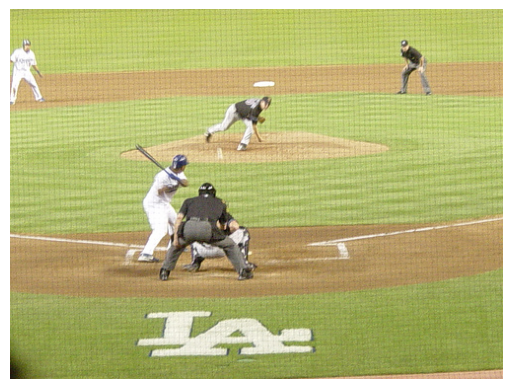

a pitcher throwing a ball towards a batter during a Dodgers game 
Three baseballs players and two referees are playing and officiating a baseball game.
A professional baseball game going on in a baseball field. 
A baseball player holding a bat while standing next to a base.
a man that is standing up at home plate


In [9]:
import numpy as np
import skimage.io as io
import matplotlib.pyplot as plt
%matplotlib inline

# pick a random image and obtain the corresponding URL
ann_id = np.random.choice(ids)
img_id = coco.anns[ann_id]['image_id']
img = coco.loadImgs(img_id)[0]
url = img['coco_url']

# print URL and visualize corresponding image
print(url)
I = io.imread(url)
plt.axis('off')
plt.imshow(I)
plt.show()

# load and display captions
annIds = coco_caps.getAnnIds(imgIds=img['id']);
anns = coco_caps.loadAnns(annIds)
coco_caps.showAnns(anns)

## Step 3: What's to Come!

In this project, you will use the dataset of image-caption pairs to train a CNN-RNN model to automatically generate captions from images.  You'll learn more about how to design the architecture in the next notebook in the sequence (**1_Preliminaries.ipynb**).

![Image Captioning CNN-RNN model](https://github.com/pradhapmoorthi/CVND/blob/Simple/images/encoder-decoder.png?raw=1)